# COMPUTACIÓN DE ALTAS PRESTACIONES - Práctica 2
## Autor: Iván Domínguez

### Ejercicio 2

Lo primero que haremos será implementar nuestra propia versión del algoritmo "Stencil 1D" para posteriormente ejecutarla a diferentes niveles de paralelización (instrucciones SIMD; instrucciones SIMD + paralelización del bucle; paralelización para GPU). 

Queremos que la versión de este algoritmo sea completamente _in-place_. Y para evitar problemas más adelante en cuestiones de paralelismo, se ha pensado implementar la versión Red-Black ordering. Consiste en evitar las condiciones de carrera sumando primero las celdas pares (las "rojas") y después las impares (las "negras"). Tal vez más adelante sea necesario modificar el algoritmo, el que se presenta a continuación no es más que una versión preliminar:

In [46]:
import numpy as np

def stencil_1d(t:np.ndarray, r:int):
    
    """ 
    
    Implementa una versión inicial del famoso algoritmo Stencil 1D. Más 
    concretamennte, su versión Red-Black ordering que trata de evitar 
    condiciones de carrera (que pueden suponer un problema más adelante). 

        t (np.ndarray): array sobre el que se aplicará el algoritmo (inplace). 
        r (int): radio de valores tenidos en cuenta. 
    
    """
    
    # Nos cercioramos de que el radio sea un entero. 
    assert isinstance(r, int), "El radio r debe ser un entero."
    # Guardamos la longitud en memoria para más adelante. 
    n = len(t)
    # Y guardamos una versión auxiliar de t para no guardar 
    # sus elementos de 1 en 1.
    t_old = t.copy() 

    # Primero operaremos sobre los pares:
    for i in range(0, n, 2):
        
        # Actualizamos el valor (suma de la vecindad)
        t[i] = np.sum(t_old[(max(0, i - r)):(min(n, i + r + 1))])

    # Y después sobre los impares:
    for i in range(1, n, 2):
        # Al ser in-place, aquí t[i-1] y t[i+1] ya podrían ser los valores nuevos
        t[i] = np.sum(t_old[(max(0, i - r)):(min(n, i + r + 1))])

    return t

Un ejemplo de uso sencillo para comprobar la funcionalidad sería el de aplicar _stencil_1d_ al array [1,2,3,4,5] con radio 2. Podemos saber trivialmente que el resultado es [6,10,15,14,12] Comprobémoslo:

In [47]:
t=np.array([1,2,3,4,5])
stencil_1d(t, 2)
t

array([ 6, 10, 15, 14, 12])

Efectivamente, el resultado es correcto y entendemos por tanto que nuestra implementación del algoritmo es correcta. 

El objetivo ahora es comparar en términos de rendimiento las distintas formas que tenemos de ejecutar esta función. Como dijimos anteriormente:

- Instrucciones SIMD: compilando la función con el decorador njit de numba. 

- Instrucciones SIMD + paralelización del bucle: compilando la función con el decorador njit de numba y usando _prange_ para paralelizar los bucles. 

- Paralelización para GPU: desharemos los bucles y usaremos índices.

**Observación**: esperamos que, en términos de rendimiento, los dos primeros métodos sean más rápidos. El problema es demasiado trivial, por lo que es esperable que resolverlo con CPU sea más rápido que tan si quiera pasar el problema a la memoria GPU (>200ms). 

### 1. Sólo instrucciones SIMD

La primera versión es muy fácil de implementar. Es más, como tal, solo tenemos que añadir el decorador y cambiar el nombre a la función.

In [48]:
from numba import njit, float64

@njit(parallel=False)
def stencil_1d_simd(t:np.ndarray, r:int):
    
    """ 
    
    Implementa una versión inicial del famoso algoritmo Stencil 1D. Más 
    concretamennte, su versión Red-Black ordering que trata de evitar 
    condiciones de carrera (que pueden suponer un problema más adelante). 

    Con la llamada al decorador @njit aseguramos la compilación del código, 
    así como las instrucciones vectorizadas. 

        t (np.ndarray): array sobre el que se aplicará el algoritmo (inplace). 
        r (int): radio de valores tenidos en cuenta. 
    
    """
    
    # Nos cercioramos de que el radio sea un entero. 
    assert isinstance(r, int), "El radio r debe ser un entero."
    # Guardamos la longitud en memoria para más adelante. 
    n = len(t)
    # Y guardamos una versión auxiliar de t para no guardar 
    # sus elementos de 1 en 1.
    t_old = t.copy() 

    # Primero operaremos sobre los pares:
    for i in range(0, n, 2):
        
        # Actualizamos el valor (suma de la vecindad)
        t[i] = np.sum(t_old[(max(0, i - r)):(min(n, i + r + 1))])

    # Y después sobre los impares:
    for i in range(1, n, 2):
        # Al ser in-place, aquí t[i-1] y t[i+1] ya podrían ser los valores nuevos
        t[i] = np.sum(t_old[(max(0, i - r)):(min(n, i + r + 1))])

    return t


### 2. Instrucciones SIMD + paralelización de bucles. 

Sin embargo, esta segunda implementación necesita algunos cambios. En concreto, _prange_ no acepta saltos de dos en dos. Por tanto, tendremos que reconstruir los índices dentro de los propios bucles. Nada muy complicado:

In [49]:
from numba import prange 

@njit(parallel=True)
def stencil_1d_parallel(t:np.ndarray, r:int):
    
    """ 
    
    Implementa una versión inicial del famoso algoritmo Stencil 1D. Más 
    concretamennte, su versión Red-Black ordering que trata de evitar 
    condiciones de carrera (que pueden suponer un problema más adelante). 

    Con la llamada al decorador @njit, no solo aseguramos la compilación del 
    código y las instrucciones vectorizadas, sino que también la paralelización
    de los bucles (ayudándonos de prange de numba). 

        t (np.ndarray): array sobre el que se aplicará el algoritmo (inplace). 
        r (int): radio de valores tenidos en cuenta. 
    
    """
    
    # Nos cercioramos de que el radio sea un entero. 
    assert isinstance(r, int), "El radio r debe ser un entero."
    # Guardamos la longitud en memoria para más adelante. 
    n = len(t)
    # Y guardamos una versión auxiliar de t para no guardar 
    # sus elementos de 1 en 1.
    t_old = t.copy() 

    # Determinamos cuántos elementos pares e impares hay
    num_pares = (n + 1) // 2
    num_impares = n // 2

    # Primero operaremos sobre los pares:
    for j in prange(num_pares):
        i = j * 2  # Reconstruimos el índice real (0, 2, 4...)
        t[i] = np.sum(t_old[(max(0, i - r)):(min(n, i + r + 1))])

    # Y después sobre los impares:
    for j in prange(num_impares):
        i = j * 2 + 1  # Reconstruimos el índice real (1, 3, 5...)
        t[i] = np.sum(t_old[(max(0, i - r)):(min(n, i + r + 1))])

    return t

Convendría hacer una llamada en frío a las funciones para que se compilen:

In [50]:
# usando el t de unas celdas atrás:
t=np.array([1,2,3,4,5])
stencil_1d_simd(t, 2)
print(t)
t=np.array([1,2,3,4,5])
stencil_1d_parallel(t, 2)
print(t)

[ 6 10 15 14 12]
[ 6 10 15 14 12]


Estas llamadas son solo para comprobar la funcionalidad. Efectivamente, ambas son correctas. 



Y ahora implementaremos una tercera versión utilizando Numba CUDA. 

Lo primero será ver si tenemos acceso a un dispositivo de procesamiento gráfico. Esta versión esta ejecutada desde Kaggle, por lo que para obtener un dispositivo, iremos a settings, accelerator y seleccionaremos el que más nos convenzca. 

**Observación:** los dispositivos gráficos de Kaggle (Nvidia Tesla T4, por ejemplo) fueron creados con la finalidad de ejecutar modelos de aprendizaje automático y programas orientados a la computación de altas prestaciones. Estas gráficas están mucho más alineadas con los propósitos de la asignatura que otras que puedan haber sido diseñadas para correr videojuegos, el tipo de gráficas que ofrecen por defecto muchas máquinas comerciales hoy en día. 

In [51]:
from numba import cuda
cuda.detect()

Found 2 CUDA devices
id 0             b'Tesla T4'                              [SUPPORTED]
                      Compute Capability: 7.5
                           PCI Device ID: 4
                              PCI Bus ID: 0
                                    UUID: GPU-a22e2851-7afb-f7b1-d142-2e08b4214b93
                                Watchdog: Disabled
             FP32/FP64 Performance Ratio: 32
id 1             b'Tesla T4'                              [SUPPORTED]
                      Compute Capability: 7.5
                           PCI Device ID: 5
                              PCI Bus ID: 0
                                    UUID: GPU-f3665f00-e475-7acf-7ebe-24e306f461e4
                                Watchdog: Disabled
             FP32/FP64 Performance Ratio: 32
Summary:
	2/2 devices are supported


True

Podemos apreciar que Kaggle nos ofrece 2 gráficas Nvidia Tesla T4 gratuitamente. Aunque solo 30 horas semanales. Seleccionaremos solo 1 de momento por motivos de sencillez, aunque cuda lo haría por defecto de no especificarlo. 

In [52]:
cuda.select_device(0)

<weakproxy at 0x7a0fbd654a40 to Device at 0x7a0fb9bb8980>

Ahora implementaremos la versión para una gráfica del algoritmo Stencil 1D. Es importante tener en cuenta que tenemos que desprendernos de los bucles. Cada hilo lanzado, ejecutará una instancia de la función que programaremos, por lo que tendremos que asociar un índice para cada hilo. Una vez asegurado esto, tendremos que cerciorar también que los índices están dentro de rango (como mucho, la longitud del array). De tener menos hilos que elementos el array, saltará un error. Casi siempre dejaremos hilos sin elemento asociado en la última iteración. 

Para controlar que la función se ejecuta por partes (primero pares, luego impares), añadiremos un parámetro _phase_. De tal forma, se deberán lanzar las 2 versiones de la función, una para los pares, otra para los impares. El resultado final se pasará de nuevo a memoria principal para poder pasarlo por pantalla. 

Para ejemplificar, ya no podemos usar el array [1,2,4,5] porque ni si quiera merece la pena pasarlo a memoria para ejecutarlo con la gráfica. Lo lógico sería probarlo con un array de, por lo menos, 1 millón de elementos. Aunque tal vez se siga quedando más que corto. 

Otra observación importante es que la implementación Red-Black ya no es acertada, pues sería necesario lanzar 2 llamadas al kernel y, por lo tanto, modificar el array sobre el ya modificado. También preferimos evitar la implementación in-place para nuestra primera toma de contacto: se implementará la versión más preliminar del algoritmo. 

In [53]:
@cuda.jit
def stencil_1d_cuda(t_in, t_out, r):
    
    """ 
    
    Implementa una versión inicial del famoso algoritmo Stencil 1D. Es 
    fácil ver como para cuda no funcionaría una implementación Red-Black, 
    pues habría que llamar al kernel 2 veces.

    Ahora no ya no hay bucles. La idea ahora es asignar a cada hilo un índice 
    a modificar. 

        t (np.ndarray): array sobre el que se aplicará el algoritmo (inplace). 
        r (int): radio de valores tenidos en cuenta. 
    
    """
    
    i = cuda.grid(1)
    n = t_in.shape[0]
    
    if i < n:
        suma = 0.0
        for j in range(max(0, i - r), min(n, i + r + 1)):
            suma += t_in[j]
            
        t_out[i] = suma

Podríamos intentar ejecutar lo siguiente, pero resultaría en un error del tipo: 

NumbaPerformanceWarning: Grid size 32 will likely result in GPU under-utilization due to low occupancy.

In [54]:
# t=np.array([1,2,3,4,5])
# d_t=cuda.to_device(t)
# n = t.shape[0]
# threads_per_block = 16
# blocks_per_grid = 32
# r=2
# stencil_1d_cuda[blocks_per_grid, threads_per_block](d_t, r, 0)
# stencil_1d_cuda[blocks_per_grid, threads_per_block](d_t, r, 1)
# d_t.copy_to_host()
# print(d_t)

Ejecutamos para 1 millón de elementos. Para comprobar la funcionalidad, lo óptimo es llamar 

In [55]:
t = np.ones(10**6)
d_t = cuda.to_device(t)
n = t.shape[0]
threads_per_block = 256
blocks_per_grid = int(np.ceil(n / threads_per_block))
r = 2
d_t_out = cuda.device_array_like(d_t)
stencil_1d_cuda[blocks_per_grid, threads_per_block](d_t, d_t_out, r)
result = d_t_out.copy_to_host()
print(result)

[3. 4. 5. ... 5. 4. 3.]


Podemos ver que, efectivamente, somos capaces de ejecutar esta versión del Stencil 1D. Ahora podemos hacer una comparativa (en tiempo) entre las 3 implementaciones probando con arrays de 100.000 a 1.000.000 en pasos de 100.000. 

**Nota:** también podemos ver como el tamaño del bloque o fijamos en función del tamaño del array. Creemos que esto es lo óptimo para tener un número de hilos mínimo para la longitud de nuestro problema. Es más, si los tamaños de los arrays fueran potencias de dos, podríamos crear un número de hilos exactamente igual al número de elementos del array, asociando un hilo a cada elemento. 

Naturalmente, lo óptimo es implementar también una versión de este kernel pero usando memoria compartida:

In [56]:
@cuda.jit
def stencil_1d_cuda_shared(t_in, t_out, r):
    """
    Versión optimizada del Stencil 1D usando memoria compartida.
    
    Cada bloque carga en shared memory:
      - Los elementos que le corresponden
      - Los 'r' elementos del halo izquierdo
      - Los 'r' elementos del halo derecho
    
    Parámetros:
        t_in  (np.ndarray): array de entrada
        t_out (np.ndarray): array de salida
        r     (int): radio del stencil
    """

    tile_size = cuda.blockDim.x + 2 * r
    s_tile = cuda.shared.array(shape=0, dtype=float64)

    n         = t_in.shape[0]
    tx        = cuda.threadIdx.x
    i_global  = cuda.grid(1)


    left_global = i_global - r
    s_idx_left  = tx

    if tx < r:
        if left_global + tx < 0 or left_global + tx >= n:
            s_tile[tx] = 0.0
        else:
            s_tile[tx] = t_in[left_global + tx]

    s_tile[tx + r] = t_in[i_global] if i_global < n else 0.0

    right_global = i_global + cuda.blockDim.x   # primer elemento del halo der.
    if tx < r:
        if right_global + tx >= n:
            s_tile[tx + cuda.blockDim.x + r] = 0.0
        else:
            s_tile[tx + cuda.blockDim.x + r] = t_in[right_global + tx]
            
    cuda.syncthreads()

    if i_global < n:
        suma = 0.0

        for j in range(tx, tx + 2 * r + 1):
            suma += s_tile[j]
        t_out[i_global] = suma

Mediremos los tiempos con la clase _Timer_ de la práctica anterior:

In [57]:
# Medición de tiempos

import time

class Timer:

    def __enter__(self):
        self.start = time.time()
        return self

    def __exit__(self, *args):
        self.end = time.time()
        self.interval = self.end - self.start

Y guardaremos un tiempo para cada tamaño y método:

In [58]:
# Medimos los tiempos de ejecución de ambas funciones de multiplicaciones de matrices en Python

# Podemos reciclar casi todo el código de antes:

tamaño = []
tiempo_simd = []
tiempo_prange = []
tiempo_cuda = []
tiempo_cuda_shared = []

n_iter = 10

for i in range(10**6, 10**7, 10**6):

    # generamos un array arbitrario de tamaño i 
    # muestreano una normal(0,1)
    array = np.random.randn(i)
    # guardamos un tal tamaño:
    tamaño.append(i)
    # fijamos un valor r=10 arbitario
    radius=10

    # - - - - Stencil 1D SIMD - - - - 
    
    # 1. Creamos un array para almacenar 10 tiempos:
    results_simd = 0
  
    for _ in range(n_iter):
      
      # 2. Medimos el tiempo y lo guardamos en el array:
      
      with Timer() as k:
        stencil_1d_simd(array, radius)
      
      result = k.interval
      results_simd += result
    
    # 3. Calculamos la media de tiempos
      
    results_simd /= n_iter
      
    # 4. Lo añadimos a los tiempos de slow
    tiempo_simd.append(results_simd)

    # - - - - Stencil 1D Parallel - - - - 
    
    # 1. Creamos un array para almacenar 10 tiempos:
    results_prange = 0
  
    for _ in range(n_iter):
      
      # 2. Medimos el tiempo y lo guardamos en el array:
      
      with Timer() as k:
        stencil_1d_parallel(array, radius)
      
      result = k.interval
      results_prange += result
    
    # 3. Calculamos la media de tiempos
      
    results_prange /= n_iter
      
    # 4. Lo añadimos a los tiempos de slow
    tiempo_prange.append(results_prange)

    # - - - - Stencil 1D CUDA - - - - 
    
    # 1. Creamos un array para almacenar 10 tiempos:
    results_cuda = 0
  
    for _ in range(n_iter):
      
      # 2. Medimos el tiempo y lo guardamos en el array:
      
      with Timer() as k:
        t = np.ones(i)
        d_t = cuda.to_device(t)
        n = t.shape[0]
        threads_per_block = 256
        blocks_per_grid = int(np.ceil(n / threads_per_block))
        r = 2
        d_t_out = cuda.device_array_like(d_t)
        stencil_1d_cuda[blocks_per_grid, threads_per_block](d_t, d_t_out, r)
        result = d_t_out.copy_to_host()

      result = k.interval
      results_cuda += result
    
    # 3. Calculamos la media de tiempos
      
    results_cuda /= n_iter
      
    # 4. Lo añadimos a los tiempos de slow
    tiempo_cuda.append(results_cuda)

    # - - - - Stencil 1D CUDA - Shared Memory - - - - 
    
    # 1. Creamos un array para almacenar 10 tiempos:
    results_cuda_shared = 0
  
    for _ in range(n_iter):
      
      # 2. Medimos el tiempo y lo guardamos en el array:
      
      with Timer() as k:
        t = np.ones(i)
        d_t = cuda.to_device(t)
        n = t.shape[0]
        threads_per_block = 256
        blocks_per_grid = int(np.ceil(n / threads_per_block))
        r = 2
        d_t_out = cuda.device_array_like(d_t)
        shared_bytes = (threads_per_block + 2 * r) * 8 
        stencil_1d_cuda_shared[blocks_per_grid, threads_per_block, 0, shared_bytes](d_t, d_t_out, np.int32(r))
        result = d_t_out.copy_to_host()

      result = k.interval
      results_cuda_shared += result
    
    # 3. Calculamos la media de tiempos
      
    results_cuda_shared /= n_iter
      
    # 4. Lo añadimos a los tiempos de slow
    tiempo_cuda_shared.append(results_cuda_shared)

Nota: podemos apreciar como los tiempos medidos para el caso de CUDA incluyen el tiempo de ida a la memoria GPU, el tiempo de procesamiento y el tiempo de vuelta.

Y graficamos para ver los resultados:

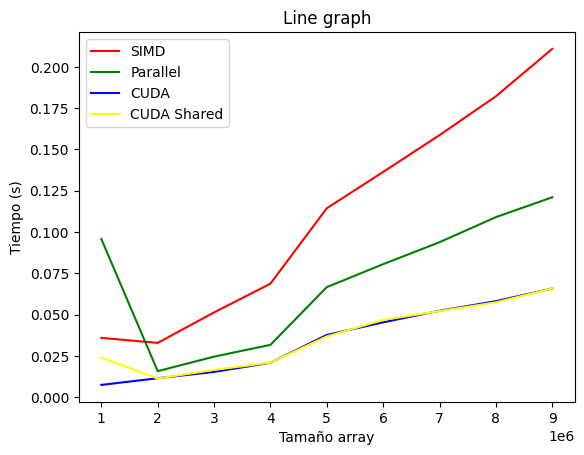

In [59]:
import matplotlib.pyplot as plt

plt.figure()
plt.title("Line graph")
plt.xlabel("Tamaño array")
plt.ylabel("Tiempo (s)")
plt.plot(tamaño, tiempo_simd, color ="red", label="SIMD")
plt.plot(tamaño, tiempo_prange, color ="green", label="Parallel")
plt.plot(tamaño, tiempo_cuda, color ="blue", label="CUDA")
plt.plot(tamaño, tiempo_cuda_shared, color ="yellow", label="CUDA Shared")
plt.legend(loc="upper left")
plt.show()

Los tiempos son bastante razonables observándolos a simple vista. Por lo que parece, casi el total del tiempo asociado a CUDA es el tiempo de ida y vuelta de memoria CPU a memoria GPU, pues el tiempo de procesamiento debería ser despreciable para la GPU para problemas tan pequeños. Eso se deja notar si apreciamos la diferencia entre CUDA y CUDA Shared. 

Como se explicaba anteriormente, el tamaño de bloque se ha creado en función del número de elementos del array. Esto es, fijando un número arbitrario de hilos por bloque -512, por ejemplo-, se crea un número mínimo de bloques de tal forma que cada elemento del array tenga asociado un hilo (habrá -pocos- hilos que no tengan un elemento del array asociado). Matemáticamente esto es la función techo del tamaño del array entre el numero de hilos por bloque:

 $$ n_{\text{bloques}} = \left\lceil\frac{\text{length}(\text{array})}{n \frac{\text{hilos}}{\text{bloque}}} \right\rceil $$

Creemos que esto es lo óptimo, pues de esta forma no se crean más hilos de los necesarios. Incluso podríamos reducir el número de hilos para que, al aumentar el número de bloques, el porcentaje de hilos sin tareas del último de los bloques sea menos (por puras cuestiones de probabilidad). Para este problema, sin embargo, el efecto es despreciable.

En cualquier caso, podríamos probar otros tamaños de hilos por bloque para comparar resultados y determinar si merece la pena pocos bloques de muchos hilos o si, por el contrario, es mejor un mayor número de bloques y un menor número de hilos. Para ello, iremos variando el número de hilos en potencias de 2: $\{1, 2, 4, ..., 512\} = \{2^p\}_{p=1}^{9}$ para arrays de tamaño fijo de 10 millones ($10^7$). 



In [60]:

# haremos 4 iteraciones por número de hilos por bloque para obtener su media.

results_cuda = []
n_iter = 10
n_threads=[]

for i in range(10):
    
    for _ in range(n_iter):
      
      # 2. Medimos el tiempo y lo guardamos en el array:
      
      with Timer() as k:
        t = np.ones(10**7)
        d_t = cuda.to_device(t)
        n = t.shape[0]
        threads_per_block = 2**i
        blocks_per_grid = int(np.ceil(n / threads_per_block))
        r = 2
        d_t_out = cuda.device_array_like(d_t)
        stencil_1d_cuda[blocks_per_grid, threads_per_block](d_t, d_t_out, r)
        result = d_t_out.copy_to_host()

      result = k.interval
      results_cuda.append(result)
      n_threads.append(str(2**i)) # en str para plotear cómodamente como si fueran tipos

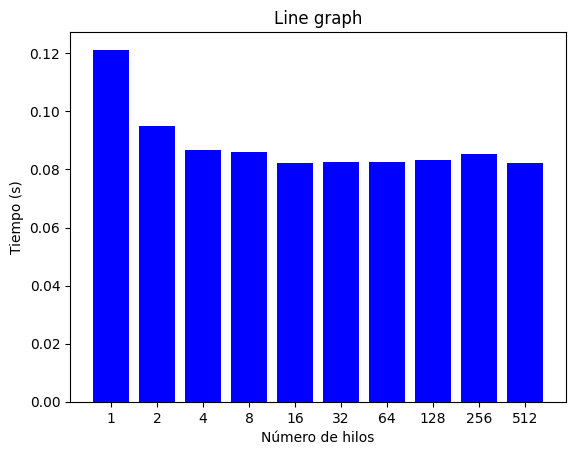

In [61]:
plt.figure()
plt.title("Line graph")
plt.xlabel("Número de hilos")
plt.ylabel("Tiempo (s)")
plt.bar(n_threads, results_cuda, color ="blue")
plt.show()

Salvando el caso de 1 o 2 hilos, parece ser bastante despreciable, al menos para tamaños tan pequeños de hilos (aunque será el número en el que nos moveremos habitualmente). 